In [1]:
import pandas as pd
pd.set_option('display.float_format', '{:.0f}'.format)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df = pd.read_csv('../datasets/kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3,1,1180,5650,1,0,0,...,7,1180,0,1955,0,98178,48,-122,1340,5650
1,6414100192,20141209T000000,538000,3,2,2570,7242,2,0,0,...,7,2170,400,1951,1991,98125,48,-122,1690,7639
2,5631500400,20150225T000000,180000,2,1,770,10000,1,0,0,...,6,770,0,1933,0,98028,48,-122,2720,8062
3,2487200875,20141209T000000,604000,4,3,1960,5000,1,0,0,...,7,1050,910,1965,0,98136,48,-122,1360,5000
4,1954400510,20150218T000000,510000,3,2,1680,8080,1,0,0,...,8,1680,0,1987,0,98074,48,-122,1800,7503


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613,4580301521,2876565571,1000102,2123049194,3904930410,7308900445,9900000190
price,21613,540088,367127,75000,321950,450000,645000,7700000
bedrooms,21613,3,1,0,3,3,4,33
bathrooms,21613,2,1,0,2,2,2,8
sqft_living,21613,2080,918,290,1427,1910,2550,13540
sqft_lot,21613,15107,41421,520,5040,7618,10688,1651359
floors,21613,1,1,1,1,2,2,4
waterfront,21613,0,0,0,0,0,0,1
view,21613,0,1,0,0,0,0,4
condition,21613,3,1,1,3,3,4,5


In [5]:
df.duplicated().sum()

0

In [6]:
df.isna().sum().sum()

0

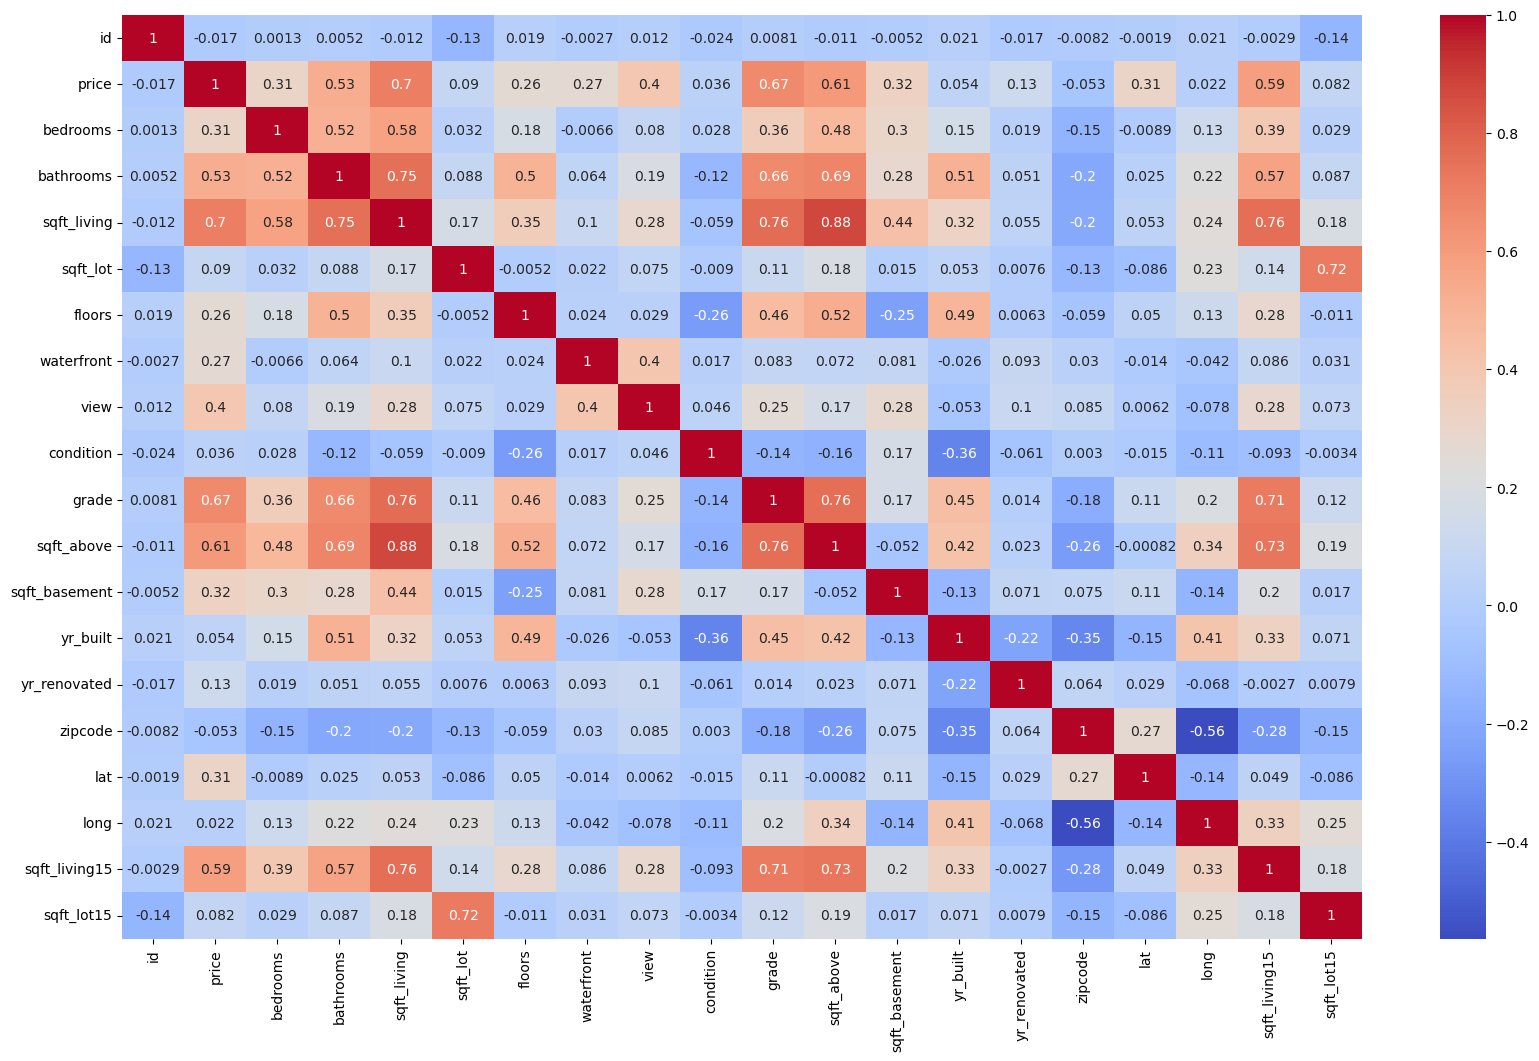

In [7]:
plt.figure(figsize=(20, 12))
sns.heatmap(df.drop(columns=['date']).corr(), annot=True, cmap='coolwarm')
plt.show()

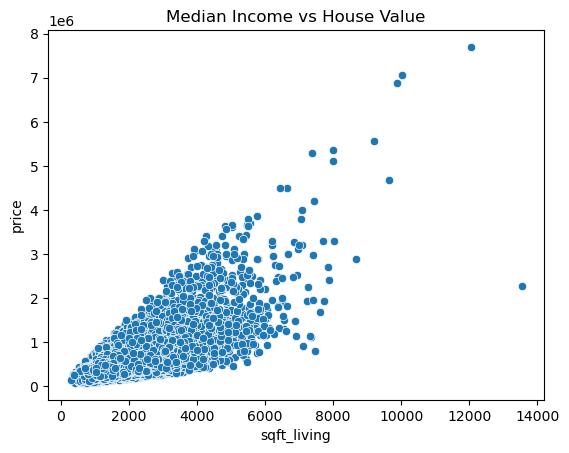

In [8]:
sns.scatterplot(x='sqft_living', y='price', data=df)
plt.title("Median Income vs House Value")
plt.show()

In [9]:
X = df.drop(['date', 'price'], axis=1)
y = df['price']

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred = model.predict(X_test)

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2*100:.2f}%")

MAE: 127474.10
R² Score: 70.12%


In [13]:
from sklearn.tree import DecisionTreeRegressor

In [14]:
X_dt_train, X_dt_test, y_dt_train, y_dt_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [15]:
dtree = DecisionTreeRegressor(random_state=42)
dtree.fit(X_dt_train, y_dt_train)

DecisionTreeRegressor(random_state=42)

In [16]:
y_dt_pred = dtree.predict(X_dt_test)

In [17]:
mae = mean_absolute_error(y_dt_test, y_dt_pred)
r2 = r2_score(y_dt_test, y_dt_pred)

print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2*100:.2f}%")

MAE: 104278.92
R2 Score: 73.60%


In [18]:
import pandas as pd
import numpy as np

# Create bins
bins = [0, 200000, 1000000, np.inf]
labels = ['Low', 'Mid', 'High']

test_df = pd.DataFrame({'actual': y_dt_test, 'predicted': y_dt_pred})
test_df['price_range'] = pd.cut(test_df['actual'], bins=bins, labels=labels)
# print(test_df)

# Calculate MAE per bin
for label in labels:
    subset = test_df[test_df['price_range'] == label]
    mae_bin = np.mean(np.abs(subset['actual'] - subset['predicted']))
    print(f"MAE for {label} price houses: {mae_bin:.2f}")

MAE for Low price houses: 74421.21
MAE for Mid price houses: 82507.45
MAE for High price houses: 392262.64


In [19]:
import pickle

with open('dtree_pickle.pkl', 'wb') as dtree_pkl:
    pickle.dump(dtree, dtree_pkl)

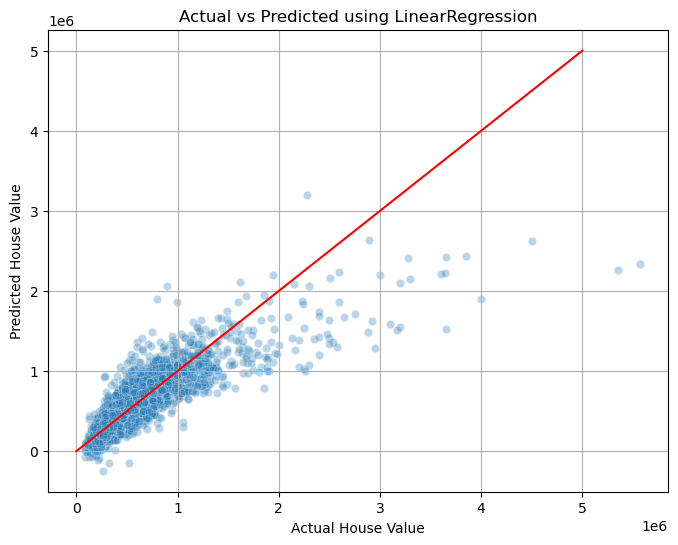

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted using LinearRegression")
plt.plot([0, 5000000], [0, 5000000], color='red')  # Line of perfect prediction
plt.grid(True)
plt.show()

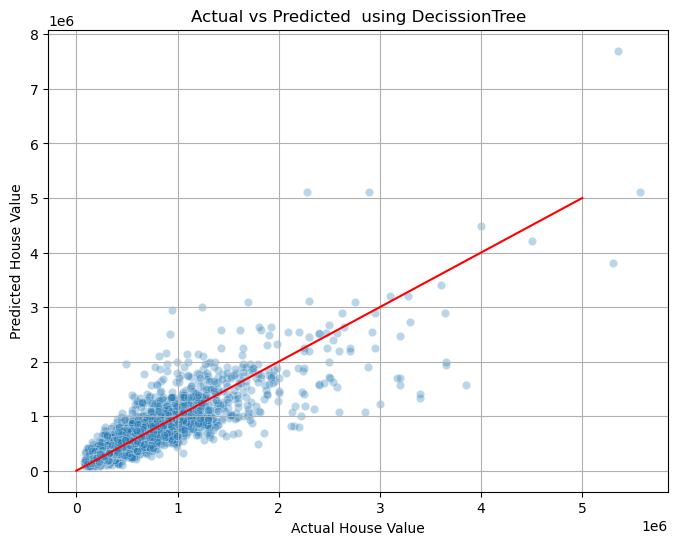

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_dt_test, y=y_dt_pred, alpha=0.3)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted  using DecissionTree")
plt.plot([0, 5000000], [0, 5000000], color='red')  # Line of perfect prediction
plt.grid(True)
plt.show()